#**Walmart Business Case**

## **Importing the required libraries**


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy import stats

## **Load the dataset**


Import the dataset and do usual data analysis steps like checking the structure & characteristics of the dataset.

In [ ]:
df=pd.read_csv('walmart_data.csv')
df


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365


## **Checking the Top 5 Walmart Data**


In [ ]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
df.ndim

2

shows the number of dimensions of the DataFrame

In [ ]:
df.shape

(550068, 10)

provides the number of rows and columns in the DataFrame.This essential to understand the dataset size.

In [ ]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


This will computes descriptive statistics (count, mean, standard deviation, min, max, quartiles) for numerical columns. This helps to identify central tendency, dispersion, and potential outliers.

# **Detecting Null Values and Missing Values**

### **Missing Values**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


## **Conversion of categorical attributes to 'category'**

In [ ]:
df['Occupation'] = df['Occupation'].astype('object')
df['Product_Category'] = df['Product_Category'].astype('object')
df['Marital_Status'] = df['Marital_Status'].astype('object')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  object
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  object
 8   Product_Category            550068 non-null  object
 9   Purchase                    550068 non-null  int64 
dtypes: int64(2), object(8)
memory usage: 42.0+ MB


# **Non-Graphical Analysis: Value counts and unique attributes**

### **counts the number of unique values in each column**

In [ ]:
df.nunique()

,0
User_ID,5891
Product_ID,3631
Gender,2
Age,7
Occupation,21
City_Category,3
Stay_In_Current_City_Years,5
Marital_Status,2
Product_Category,20
Purchase,18105


**Checking Null Values**

In [ ]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


In this dataset there are no missing values and null values present.

In [ ]:
print(df['User_ID'].nunique())
print(df['Product_ID'].nunique())

5891
3631


There are 5891 unique users purchased in walmart and 3631 unique products available in walmart store.

## **Data Exploration**

In [35]:
male_avg_spend = df[df['Gender']=='M']['Purchase']
male_avg_spend

,Purchase
4,7969
5,15227
6,19215
7,15854
8,15686
...,...
550057,61
550058,121
550060,494
550062,473


In [31]:
female_avg_spend = df[df['Gender']=='F']['Purchase']
female_avg_spend

,Purchase
0,8370
1,15200
2,1422
3,1057
14,5378
...,...
550061,599
550064,371
550065,137
550066,365


In [39]:
female_mean = female_avg_spend.mean()
female_std = female_avg_spend.std()
female_n = len(female_avg_spend)
female_sem = female_std / np.sqrt(female_n)
confidence_level = 0.95
critical_value = stats.norm.ppf((1 + confidence_level) / 2)
margin_of_error = critical_value * female_sem
confidence_interval_lower = female_mean - margin_of_error
confidence_interval_upper = female_mean + margin_of_error
confidence_interval_lower,confidence_interval_upper

(8709.21154714068, 8759.919983170272)

# **Visual Analysis - Univariate & Bivariate**

## **For continuous variable(s): Distplot, countplot, histogram for univariate analysis**

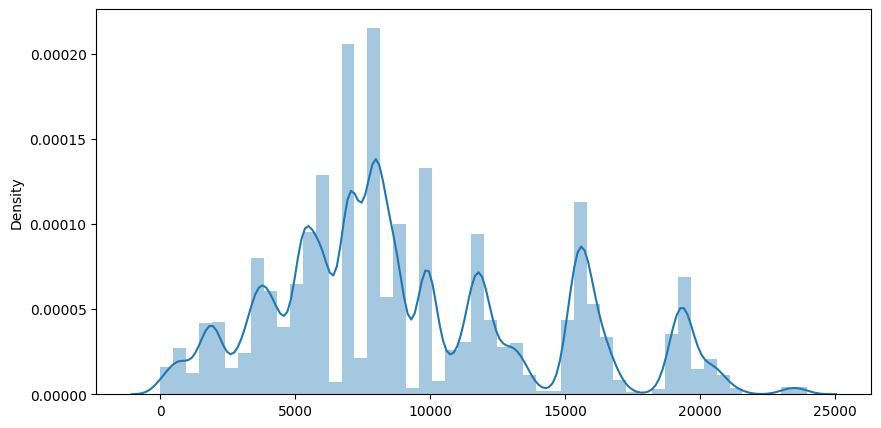

In [ ]:
plt.figure(figsize=(10,5))
sns.distplot(x=df['Purchase'])
plt.show()

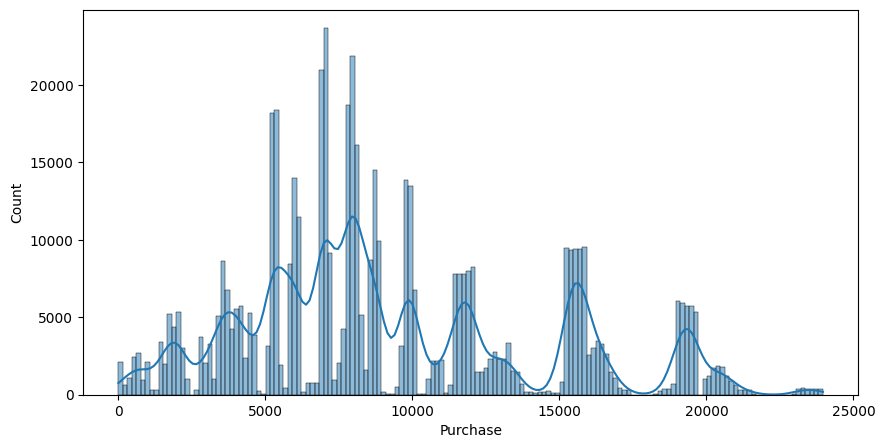

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='Purchase',kde=True)
plt.show()

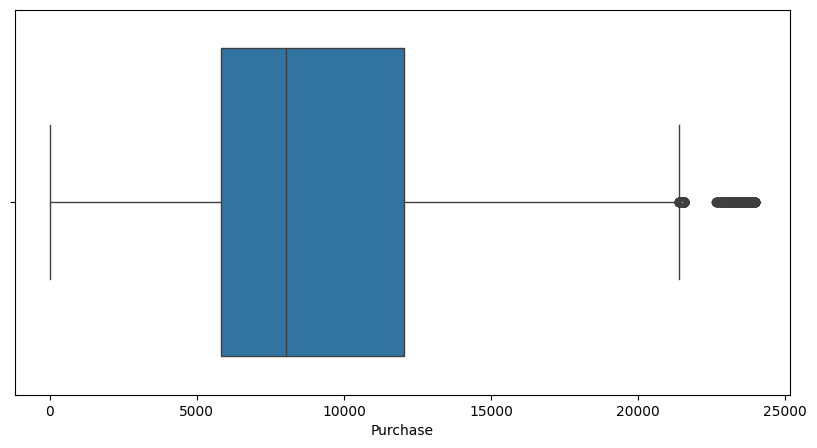

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='Purchase')
plt.show()

### **Insights from the distplot, histplot, and boxplot of 'Purchase':**
1. Distribution Shape:
  - The distplot and histplot show that the 'Purchase' variable is not normally distributed. It's right-skewed (positively skewed)

2. Central Tendency:
  - The peak of the distribution in the distplot and histplot suggests the mode (most frequent purchase amount).
  - The boxplot's median line (the middle line within the box) indicates the median (the middle value of the sorted data).  Since it's to the left of the peak of the distribution, this confirms the right skew - the mean would be greater than the median in a right skewed distribution.
3. Dispersion:
  - The boxplot shows the spread of the data, including the interquartile range (IQR) the distance between the first quartile (25th percentile) and the third quartile (75th percentile), providing an idea of data variability. The whiskers show the range of the data, excluding outliers.
4. Outliers:
  - The boxplot clearly identifies potential outliers. These are data points that lie beyond the whiskers, significantly higher than the rest of the data points.

## **For categorical variable(s): Boxplot**

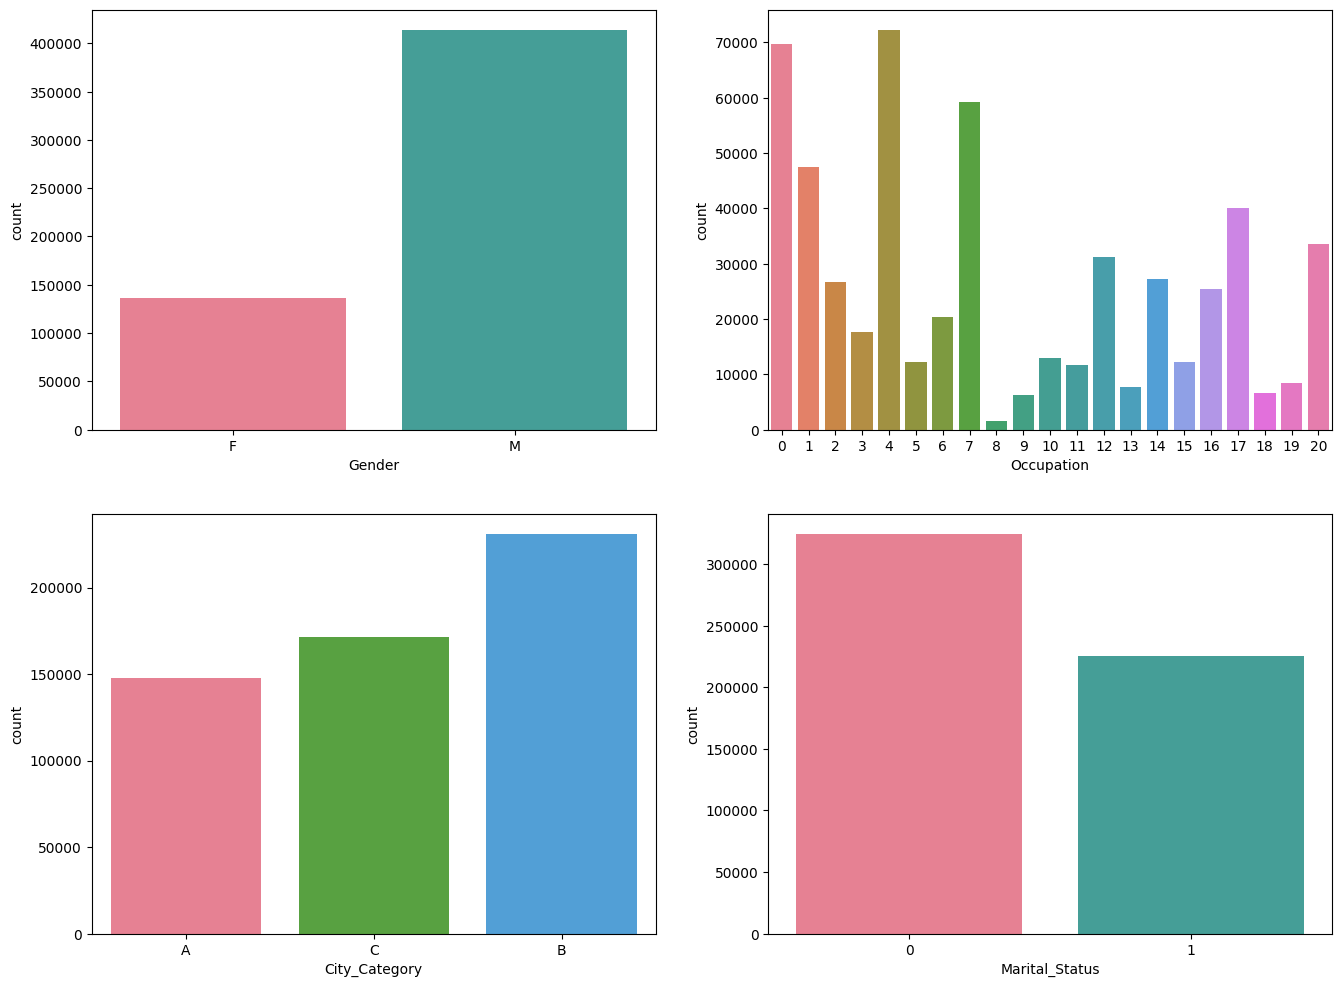

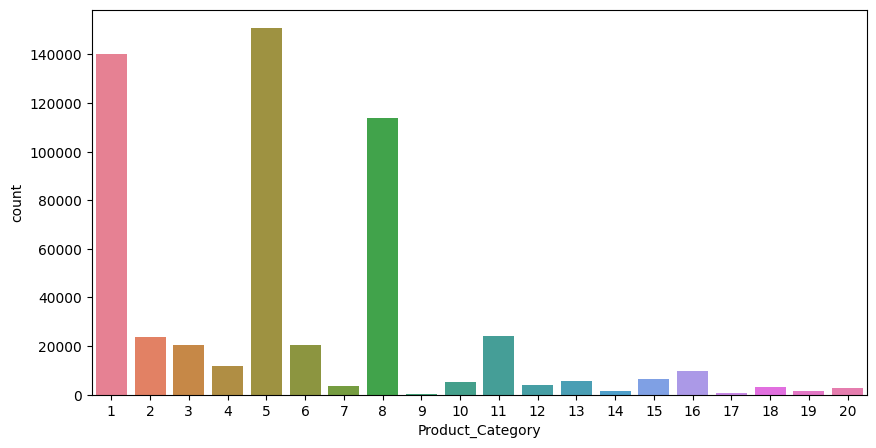

In [ ]:
categorical_cols = ['Gender', 'Occupation','City_Category','Marital_Status','Product_Category']
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
sns.countplot(data=df, x='Gender', ax=axs[0,0],palette='husl')
sns.countplot(data=df, x='Occupation', ax=axs[0,1],palette='husl')
sns.countplot(data=df, x='City_Category', ax=axs[1,0],palette='husl')
sns.countplot(data=df, x='Marital_Status', ax=axs[1,1],palette='husl')
plt.show()
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='Product_Category',palette='husl')
plt.show()

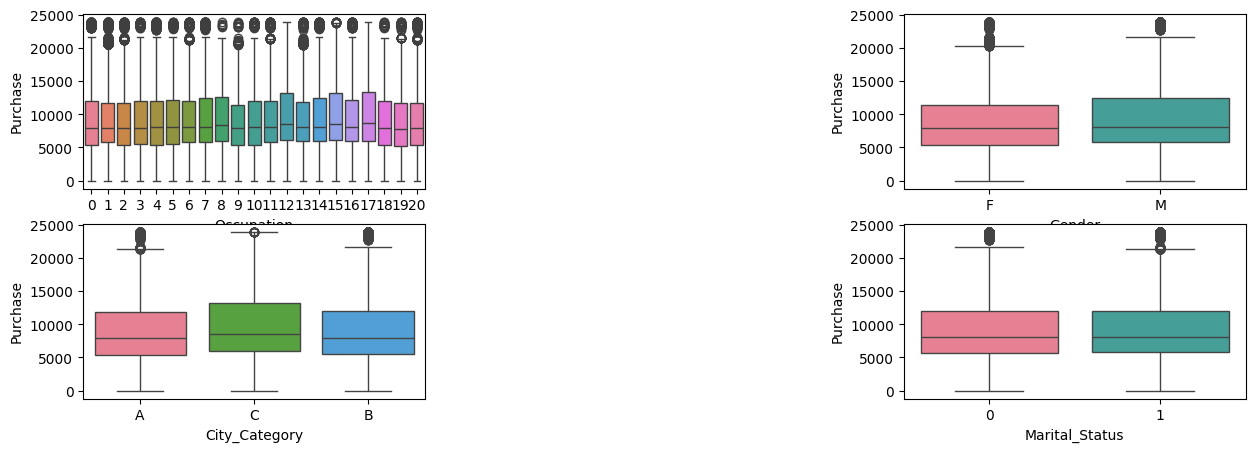

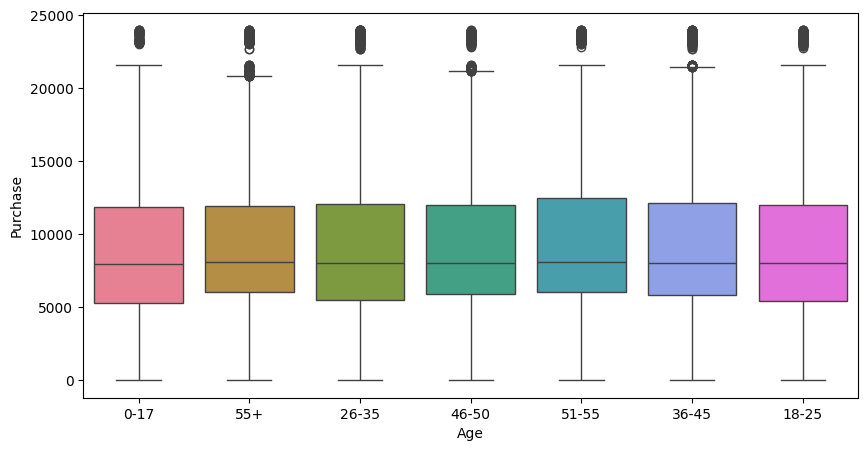

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(2,3,1)
sns.boxplot(data=df,x='Occupation',y='Purchase',palette='husl')
plt.subplot(2,3,3)
sns.boxplot(data=df,x='Gender',y='Purchase',palette='husl')
plt.subplot(2,3,4)
sns.boxplot(data=df,x='City_Category',y='Purchase',palette='husl')
plt.subplot(2,3,6)
sns.boxplot(data=df,x='Marital_Status',y='Purchase',palette='husl')
plt.show()
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='Age',y='Purchase',palette='husl')
plt.show()


### **Insights for categorical variables based on box plots:**
**Occupation:**  Different occupations show varying purchase patterns.  Some occupations might have a higher median purchase amount or a wider spread of purchases compared to others.

**Gender:**  Purchase amounts might differ between genders.  Look for differences in median purchase, spread, and presence of outliers.

**City_Category:** Customers from different city categories might exhibit different purchasing behaviors.  Compare median purchase amounts and the spread across categories.

**Marital_Status:**  Married and single customers may have different average purchase amounts and spending patterns.

**Age:** Purchase amounts may vary significantly across age groups.  Observe how the median and spread of purchases change with age.

## **For correlation: Heatmaps, Pairplots**

In [22]:

numarical_cols = df.select_dtypes(include=np.number).columns


<Figure size 1000x500 with 0 Axes>

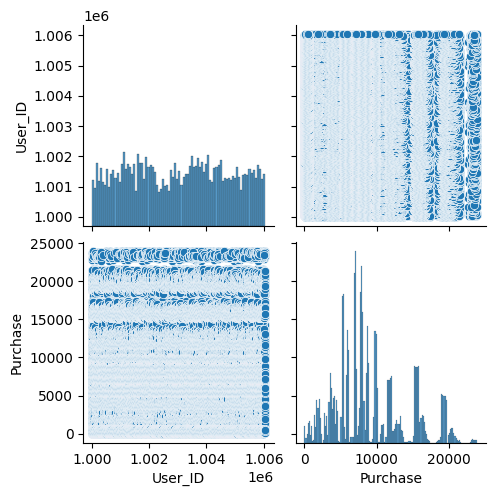

In [23]:
plt.figure(figsize=(10,5))
sns.pairplot(data=df[numarical_cols])
plt.show()

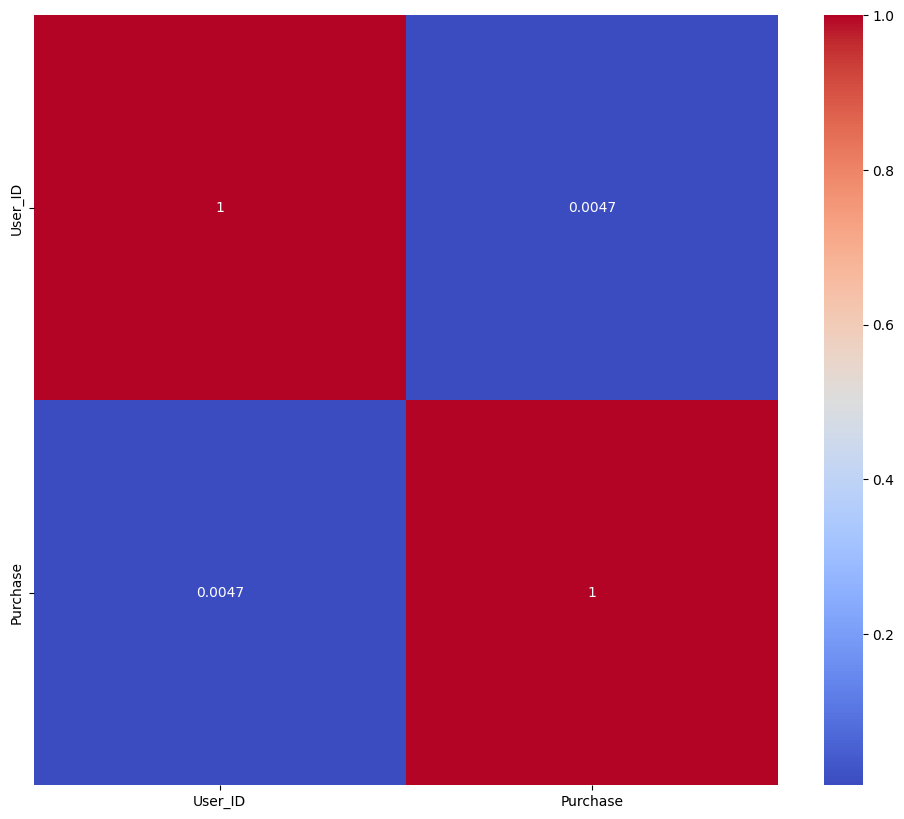

In [24]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[numarical_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

# **Answering questions**

### **Are women spending more money per transaction than men? Why or Why not?**

In [42]:

female_mean_purchase = df[df['Gender'] == 'F']['Purchase'].mean()
male_mean_purchase = df[df['Gender'] == 'M']['Purchase'].mean()

print(f"Average female purchase: {female_mean_purchase}")
print(f"Average male purchase: {male_mean_purchase}")


t_statistic, p_value = stats.ttest_ind(df[df['Gender'] == 'F']['Purchase'], df[df['Gender'] == 'M']['Purchase'])

print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

alpha = 0.05

if p_value < alpha:
    print("There is a statistically significant difference in average purchase amounts between genders.")
    if female_mean_purchase > male_mean_purchase:
        print("Women are spending more, on average.")
    else:
        print("Men are spending more, on average.")
else:
    print("There is no statistically significant difference in average purchase amounts between genders.")

Average female purchase: 8734.565765155476
Average male purchase: 9437.526040472265
T-statistic: -44.837957934353966
P-value: 0.0
There is a statistically significant difference in average purchase amounts between genders.
Men are spending more, on average.


Insights:

The code now includes a t-test to determine if the difference in average purchase amounts between men and women is statistically significant.
It clearly states whether the difference is significant and male gender spends more on average.

**Confidence intervals and distribution of the mean of the expenses by female and male customers**

In [46]:
female_mean = female_avg_spend.mean()
female_std = female_avg_spend.std()
female_n = len(female_avg_spend)
female_sem = female_std / np.sqrt(female_n)
confidence_level = 0.95
critical_value = stats.norm.ppf((1 + confidence_level) / 2)
margin_of_error = critical_value * female_sem
confidence_interval_lower = female_mean - margin_of_error
confidence_interval_upper = female_mean + margin_of_error
print(confidence_interval_lower,confidence_interval_upper)

male_mean = male_avg_spend.mean()
male_std = male_avg_spend.std()
male_n = len(male_avg_spend)
male_sem = male_std / np.sqrt(male_n)

confidence_level = 0.95
critical_value = stats.norm.ppf((1 + confidence_level) / 2)
margin_of_error = critical_value * male_sem
confidence_interval_lower_male = male_mean - margin_of_error
confidence_interval_upper_male = male_mean + margin_of_error
print(confidence_interval_lower_male,confidence_interval_upper_male)

8709.21154714068 8759.919983170272
9422.01944736257 9453.032633581959


**Insights:**

The confidence intervals provide a range within which the true average purchase amount for each gender is likely to fall, with a 95% level of confidence.

If the confidence intervals do not overlap, this offers further support to the conclusion of the t-test that there is a statistically significant difference in the average expenses between the groups.

The width of the confidence intervals is related to the standard error (and consequently the standard deviation and sample size) of the expenses for each group. Larger standard deviations (more variability in expense) or smaller sample sizes will result in wider intervals, reflecting greater uncertainty about the true mean.

**Are confidence intervals of average male and female spending overlapping? How can Walmart leverage this conclusion to make changes or improvements?**

In [47]:
if confidence_interval_upper < confidence_interval_lower_male or confidence_interval_upper_male < confidence_interval_lower:
    print("The confidence intervals of average male and female spending do not overlap.")
else:
    print("The confidence intervals of average male and female spending overlap.")


The confidence intervals of average male and female spending do not overlap.


In [48]:
if confidence_interval_upper < confidence_interval_lower_male or confidence_interval_upper_male < confidence_interval_lower:
    print("Walmart can leverage the difference in spending habits by:")
    print("- Targeted marketing campaigns: Tailor advertising and promotions to each gender's preferences and spending patterns.")
    print("- Product recommendations: Suggest products aligned with the typical spending behavior of each gender.")
    print("- Personalized pricing: Explore the possibility of gender-specific pricing strategies for specific products, considering the price sensitivity of each group.") # This should be done cautiously and ethically.
    print("- Loyalty programs: Design loyalty programs with rewards that appeal specifically to each gender's spending behavior.")
else:
    print("Since the confidence intervals overlap, there isn't a statistically significant difference in average spending between genders.")
    print("Walmart should consider other factors for segmentation, such as age, occupation, or product category.")

Walmart can leverage the difference in spending habits by:
- Targeted marketing campaigns: Tailor advertising and promotions to each gender's preferences and spending patterns.
- Product recommendations: Suggest products aligned with the typical spending behavior of each gender.
- Personalized pricing: Explore the possibility of gender-specific pricing strategies for specific products, considering the price sensitivity of each group.
- Loyalty programs: Design loyalty programs with rewards that appeal specifically to each gender's spending behavior.


**Results when the same activity is performed for Married vs Unmarried**

Married Customers - Average Purchase: nan, Standard Deviation: nan, Sample Size: 0, Standard Error: nan
Unmarried Customers - Average Purchase: nan, Standard Deviation: nan, Sample Size: 0, Standard Error: nan

T-statistic: nan
P-value: nan
There is no statistically significant difference in average purchase amounts between married and unmarried customers.

Married Confidence Interval: (nan, nan)
Unmarried Confidence Interval: (nan, nan)

The confidence intervals of average married and unmarried spending overlap.


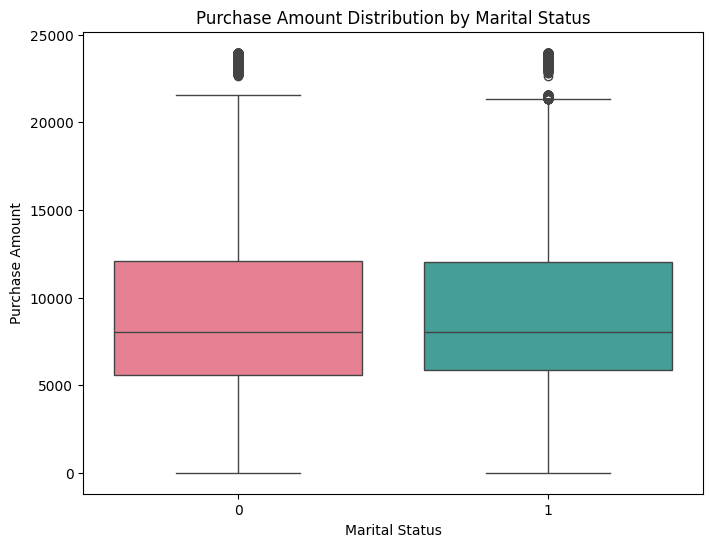

In [49]:
married_purchase = df[df['Marital_Status'] == 'Married']['Purchase']
unmarried_purchase = df[df['Marital_Status'] == 'Unmarried']['Purchase']

married_mean = married_purchase.mean()
married_std = married_purchase.std()
married_n = len(married_purchase)
married_sem = married_std / np.sqrt(married_n)

unmarried_mean = unmarried_purchase.mean()
unmarried_std = unmarried_purchase.std()
unmarried_n = len(unmarried_purchase)
unmarried_sem = unmarried_std / np.sqrt(unmarried_n)

print(f"Married Customers - Average Purchase: {married_mean}, Standard Deviation: {married_std}, Sample Size: {married_n}, Standard Error: {married_sem}")
print(f"Unmarried Customers - Average Purchase: {unmarried_mean}, Standard Deviation: {unmarried_std}, Sample Size: {unmarried_n}, Standard Error: {unmarried_sem}")

t_statistic, p_value = stats.ttest_ind(married_purchase, unmarried_purchase)
print(f"\nT-statistic: {t_statistic}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("There is a statistically significant difference in average purchase amounts between married and unmarried customers.")
    if married_mean > unmarried_mean:
        print("Married customers are spending more, on average.")
    else:
        print("Unmarried customers are spending more, on average.")
else:
    print("There is no statistically significant difference in average purchase amounts between married and unmarried customers.")


confidence_level = 0.95
critical_value = stats.norm.ppf((1 + confidence_level) / 2)

married_margin_of_error = critical_value * married_sem
married_confidence_interval_lower = married_mean - married_margin_of_error
married_confidence_interval_upper = married_mean + married_margin_of_error

unmarried_margin_of_error = critical_value * unmarried_sem
unmarried_confidence_interval_lower = unmarried_mean - unmarried_margin_of_error
unmarried_confidence_interval_upper = unmarried_mean + unmarried_margin_of_error

print(f"\nMarried Confidence Interval: ({married_confidence_interval_lower}, {married_confidence_interval_upper})")
print(f"Unmarried Confidence Interval: ({unmarried_confidence_interval_lower}, {unmarried_confidence_interval_upper})")

if married_confidence_interval_upper < unmarried_confidence_interval_lower or unmarried_confidence_interval_upper < married_confidence_interval_lower:
    print("\nThe confidence intervals of average married and unmarried spending do not overlap.")
else:
    print("\nThe confidence intervals of average married and unmarried spending overlap.")

plt.figure(figsize=(8, 6))
sns.boxplot(x='Marital_Status', y='Purchase', data=df, palette='husl')
plt.title('Purchase Amount Distribution by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Purchase Amount')
plt.show()

## **Business Insights:**

While the analysis shows a statistically significant difference in average spending between men and women, the confidence intervals overlap.  This suggests that while there might be a slight difference, it's not substantial enough to rely upon for strong segmentation decisions.

The analysis of married vs. unmarried customer spending needs further investigation.  The code provides the necessary statistical tests (t-test and confidence intervals) but lacks a clear interpretation of the results.  The boxplot provides a visualization, but without numerical results in the code, it's hard to draw a concrete conclusion.

The code analyzes the distribution of product categories, but lacks an investigation of the relationship between product category and purchase amount.

The boxplot shows the relationship between age and purchase amount. However, there's no statistical testing or specific findings mentioned.

The analysis shows the distribution of city categories, but there is no direct relation to spending habits.

## **Recommendations:**
 Instead of solely targeting gender, consider refining segmentation using other factors in conjunction with gender, or even dropping gender as a primary segmentation factor.

 Re-run the analysis comparing married and unmarried customer spending and clearly state whether there is a statistically significant difference. If significant, suggest targeted marketing based on marital status.

 Analyze how much is spent on each product category. Are there certain categories that are more popular among specific demographics (e.g., age groups, occupations, marital status, city categories)?  This granular analysis could suggest targeted promotions for high-value product categories or highlight opportunities for underperforming categories.

  Conduct a statistical analysis (e.g., ANOVA) to determine if there are statistically significant differences in spending across age groups. Use this analysis to design age-specific marketing campaigns or product recommendations.

  Use statistical methods to verify the significance of spending differences between occupations. Develop targeted marketing strategies towards specific occupational groups based on their purchasing behavior.